In [53]:
import pandas as pd
from bs4 import BeautifulSoup
import requests

df = pd.read_csv("isw_russian_offensive_updates.csv")

df.head()

,date,link
0,2026-07-23,https://understandingwar.org/research/russia-u...
1,2026-07-22,https://understandingwar.org/research/russia-u...
2,2026-07-21,https://understandingwar.org/research/russia-u...
3,2026-07-20,https://understandingwar.org/research/russia-u...
4,2026-07-19,https://understandingwar.org/research/russia-u...


In [54]:
df = df[:10]
df

,date,link
0,2026-07-23,https://understandingwar.org/research/russia-u...
1,2026-07-22,https://understandingwar.org/research/russia-u...
2,2026-07-21,https://understandingwar.org/research/russia-u...
3,2026-07-20,https://understandingwar.org/research/russia-u...
4,2026-07-19,https://understandingwar.org/research/russia-u...
5,2026-07-18,https://understandingwar.org/research/russia-u...
6,2026-07-17,https://understandingwar.org/research/russia-u...
7,2026-07-16,https://understandingwar.org/research/russia-u...
8,2026-07-15,https://understandingwar.org/research/russia-u...
9,2026-07-14,https://understandingwar.org/research/russia-u...


In [55]:
df['link'][0]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}
url = df['link'][0]
response = requests.get(url, headers=headers)


soup = BeautifulSoup(response.text, 'html.parser')

In [56]:
response.text

'<!DOCTYPE html>\n<html lang="en-US">\n<head>\n\t<meta charset="UTF-8">\n\t<meta name=\'robots\' content=\'index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1\' />\n<meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover">\n\t<!-- This site is optimized with the Yoast SEO Premium plugin v28.0 (Yoast SEO v28.0) - https://yoast.com/product/yoast-seo-premium-wordpress/ -->\n\t<title>Russian Offensive Campaign Assessment, July 23, 2026 | ISW</title>\n<link data-rocket-prefetch href="https://www.googletagmanager.com" rel="dns-prefetch">\n<link data-rocket-prefetch href="https://cdn.fundraiseup.com" rel="dns-prefetch">\n<link data-rocket-prefetch href="https://www.gstatic.com" rel="dns-prefetch">\n<link data-rocket-prefetch href="https://cdn.jsdelivr.net" rel="dns-prefetch">\n<link data-rocket-prefetch href="https://www.google.com" rel="dns-prefetch">\n<link data-rocket-prefetch href="https://static.fundraiseup.com" rel="dns-prefetch">\

In [57]:
df['link'][0]


'https://understandingwar.org/research/russia-ukraine/russian-offensive-campaign-assessment-july-23-2026/'

In [58]:
find = soup.find_all('div', id='printable-area')

In [59]:
find

[<div id="printable-area"><div class="dynamic-entry-content">
 <div class="gb-element-f40f39d3" data-id="toplines" title="Toplines">
 <p class="wp-block-paragraph"><strong><em>Note: </em></strong><em>Today’s update includes static maps only of areas in which noteworthy changes or events occurred.</em></p>
 <p class="wp-block-paragraph"></p>
 <p class="wp-block-paragraph"><em><strong>Correction:</strong> An earlier version of this update included a duplicate of a Key Takeaway. We have amended the duplicate with the correct Key Takeaway to cover Ukraine’s and Russia’s strike campaigns.</em></p>
 <p class="wp-block-paragraph"></p>
 <h2 class="gb-text">Toplines</h2>
 <p class="wp-block-paragraph"><strong>US Secretary of State Marco Rubio rejected the Russian narrative that the United States and Russia reached any kind of an agreement to end Russia’s war in Ukraine during the August 2025 Alaska Summit. </strong>Rubio stated following his meeting with Russian Foreign Minister Sergei Lavrov o

In [60]:
if find:
    clean_text = find[0].get_text(separator=" ", strip=True)

In [61]:
clean_text

'Note: Today’s update includes static maps only of areas in which noteworthy changes or events occurred. Correction: An earlier version of this update included a duplicate of a Key Takeaway. We have amended the duplicate with the correct Key Takeaway to cover Ukraine’s and Russia’s strike campaigns. Toplines US Secretary of State Marco Rubio rejected the Russian narrative that the United States and Russia reached any kind of an agreement to end Russia’s war in Ukraine during the August 2025 Alaska Summit. Rubio stated following his meeting with Russian Foreign Minister Sergei Lavrov on July 23 that Russian “proposals” at the Anchorage Summit failed and that peace will only come through new “concepts and ideas,” which Rubio stated the United States is willing to support.[1] Russian Ministry of Foreign Affairs (MFA) claimed on July 23 that Lavrov reaffirmed to Rubio Russia’s readiness for negotiations and commitment to US “proposals,” to which Russian President Vladimir Putin agreed at t

In [62]:
import re

text = re.sub(r"\[\d+\]", "", clean_text)
text = re.sub(r"\(\s*\)", "", text)

text = re.sub(r"Endnotes.*", "", text, flags=re.S)

text = re.sub(r"\S+\.(com|org|ua|ru|gov)\S*", "", text)
text = re.sub(r"\bdot\b", "", text)

text = re.sub(r"\s+", " ", text).strip()

text

'Note: Today’s update includes static maps only of areas in which noteworthy changes or events occurred. Correction: An earlier version of this update included a duplicate of a Key Takeaway. We have amended the duplicate with the correct Key Takeaway to cover Ukraine’s and Russia’s strike campaigns. Toplines US Secretary of State Marco Rubio rejected the Russian narrative that the United States and Russia reached any kind of an agreement to end Russia’s war in Ukraine during the August 2025 Alaska Summit. Rubio stated following his meeting with Russian Foreign Minister Sergei Lavrov on July 23 that Russian “proposals” at the Anchorage Summit failed and that peace will only come through new “concepts and ideas,” which Rubio stated the United States is willing to support. Russian Ministry of Foreign Affairs (MFA) claimed on July 23 that Lavrov reaffirmed to Rubio Russia’s readiness for negotiations and commitment to US “proposals,” to which Russian President Vladimir Putin agreed at the 

In [63]:
def get_text(url):
    headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}
    response = requests.get(url, headers=headers)


    soup = BeautifulSoup(response.text, 'html.parser')
    find = soup.find_all('div', id='printable-area')
    if find:
        clean_text = find[0].get_text(separator=" ", strip=True)
    text = re.sub(r"\[\d+\]", "", clean_text)
    text = re.sub(r"\(\s*\)", "", text)

    text = re.sub(r"Endnotes.*", "", text, flags=re.S)

    text = re.sub(r"\S+\.(com|org|ua|ru|gov)\S*", "", text)
    text = re.sub(r"\bdot\b", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [64]:
new_text = get_text(df['link'][1])

new_text

'Note: Today’s update includes static maps only of areas in which noteworthy changes or events occurred. Toplines The Kremlin continues to reiterate Russia’s commitment to its maximalist war aims of complete Ukrainian capitulation while Russian forces fail to achieve operationally significant gains. Kremlin Spokesperson Dmitry Peskov claimed on July 22 that Russian President Vladimir Putin’s June 2024 speech emphasizing Russia’s maximalist war aims, including Ukraine’s complete withdrawal from Ukrainian-controlled territory in Luhansk, Donetsk, Zaporizhia, and Kherson oblasts and the abandonment of Ukraine’s NATO accession aspirations before any peace negotiations, are still the basis of the Kremlin’s conditions for ending the war in Ukraine. Bloomberg reported on July 22, citing three people close to the Kremlin, that Russia is unwilling to return any Russian-occupied territories in Ukraine as part of any peace proposal and that Putin is committed to the military seizure of the remain

In [65]:
for i, x in enumerate(df['link']):
    text = get_text(x)
    df.at[i, 'text'] = text

In [66]:
df

,date,link,text
0,2026-07-23,https://understandingwar.org/research/russia-u...,Note: Today’s update includes static maps only...
1,2026-07-22,https://understandingwar.org/research/russia-u...,Note: Today’s update includes static maps only...
2,2026-07-21,https://understandingwar.org/research/russia-u...,Note: Today’s update includes static maps only...
3,2026-07-20,https://understandingwar.org/research/russia-u...,Note: Today’s update includes static maps only...
4,2026-07-19,https://understandingwar.org/research/russia-u...,Note: Today’s update includes static maps only...
5,2026-07-18,https://understandingwar.org/research/russia-u...,Toplines Russian Chief of the General Staff Ar...
6,2026-07-17,https://understandingwar.org/research/russia-u...,Toplines The Russian Ministry of Defense (MoD)...
7,2026-07-16,https://understandingwar.org/research/russia-u...,Toplines The Ukrainian government approved a s...
8,2026-07-15,https://understandingwar.org/research/russia-u...,Toplines Russian forces are resuming their str...
9,2026-07-14,https://understandingwar.org/research/russia-u...,Toplines Russian Ministry of Defense (MoD) rec...


In [67]:
df.to_csv('scraped_last_10_dates.csv', index=False)

In [68]:
text = df['text'][0]
text

'Note: Today’s update includes static maps only of areas in which noteworthy changes or events occurred. Correction: An earlier version of this update included a duplicate of a Key Takeaway. We have amended the duplicate with the correct Key Takeaway to cover Ukraine’s and Russia’s strike campaigns. Toplines US Secretary of State Marco Rubio rejected the Russian narrative that the United States and Russia reached any kind of an agreement to end Russia’s war in Ukraine during the August 2025 Alaska Summit. Rubio stated following his meeting with Russian Foreign Minister Sergei Lavrov on July 23 that Russian “proposals” at the Anchorage Summit failed and that peace will only come through new “concepts and ideas,” which Rubio stated the United States is willing to support. Russian Ministry of Foreign Affairs (MFA) claimed on July 23 that Lavrov reaffirmed to Rubio Russia’s readiness for negotiations and commitment to US “proposals,” to which Russian President Vladimir Putin agreed at the 

In [69]:
df['text'] = df['text'].str.lower()

In [70]:
df['text'] = df['text'].str.replace(r'[^\w\s]', ' ', regex=True)
df['text'] = df['text'].str.replace(r'\d+', ' ', regex=True)
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()



In [71]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

sw = stopwords.words('english')
df['text'] = df['text'].apply(lambda x: " ".join(i for i in str(x).split() if i not in sw))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mrgan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [73]:
df['text'][0]

'note today update includes static maps areas noteworthy changes events occurred correction earlier version update included duplicate key takeaway amended duplicate correct key takeaway cover ukraine russia strike campaigns toplines us secretary state marco rubio rejected russian narrative united states russia reached kind agreement end russia war ukraine august alaska summit rubio stated following meeting russian foreign minister sergei lavrov july russian proposals anchorage summit failed peace come new concepts ideas rubio stated united states willing support russian ministry foreign affairs mfa claimed july lavrov reaffirmed rubio russia readiness negotiations commitment us proposals russian president vladimir putin agreed alaska summit russian officials routinely invoke alleged anchorage agreements advance narratives russia willingness negotiate despite lack public statements following summit us officials recent rejections russian narratives ukrainian president volodymyr zelensky 

In [74]:
df['text']

0    note today update includes static maps areas n...
1    note today update includes static maps areas n...
2    note today update includes static maps areas n...
3    note today update includes static maps areas n...
4    note today update includes static maps areas n...
5    toplines russian chief general staff army gene...
6    toplines russian ministry defense mod appears ...
7    toplines ukrainian government approved series ...
8    toplines russian forces resuming strike campai...
9    toplines russian ministry defense mod recruitm...
Name: text, dtype: str

In [75]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------- ------------------ 6.8/12.8 MB 36.4 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 36.3 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 30.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("Model loaded successfully!")

Model loaded successfully!


In [78]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize(text):
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc]

df["lemmas"] = df["text"].apply(lemmatize)

In [79]:
df

,date,link,text,lemmas
0,2026-07-23,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
1,2026-07-22,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
2,2026-07-21,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
3,2026-07-20,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
4,2026-07-19,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
5,2026-07-18,https://understandingwar.org/research/russia-u...,toplines russian chief general staff army gene...,"[toplines, russian, chief, general, staff, arm..."
6,2026-07-17,https://understandingwar.org/research/russia-u...,toplines russian ministry defense mod appears ...,"[toplines, russian, ministry, defense, mod, ap..."
7,2026-07-16,https://understandingwar.org/research/russia-u...,toplines ukrainian government approved series ...,"[toplines, ukrainian, government, approve, ser..."
8,2026-07-15,https://understandingwar.org/research/russia-u...,toplines russian forces resuming strike campai...,"[toplines, russian, force, resume, strike, cam..."
9,2026-07-14,https://understandingwar.org/research/russia-u...,toplines russian ministry defense mod recruitm...,"[toplines, russian, ministry, defense, mod, re..."


In [80]:
count = df['lemmas'][0].count("drone")
count

18

In [81]:
df

,date,link,text,lemmas
0,2026-07-23,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
1,2026-07-22,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
2,2026-07-21,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
3,2026-07-20,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
4,2026-07-19,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar..."
5,2026-07-18,https://understandingwar.org/research/russia-u...,toplines russian chief general staff army gene...,"[toplines, russian, chief, general, staff, arm..."
6,2026-07-17,https://understandingwar.org/research/russia-u...,toplines russian ministry defense mod appears ...,"[toplines, russian, ministry, defense, mod, ap..."
7,2026-07-16,https://understandingwar.org/research/russia-u...,toplines ukrainian government approved series ...,"[toplines, ukrainian, government, approve, ser..."
8,2026-07-15,https://understandingwar.org/research/russia-u...,toplines russian forces resuming strike campai...,"[toplines, russian, force, resume, strike, cam..."
9,2026-07-14,https://understandingwar.org/research/russia-u...,toplines russian ministry defense mod recruitm...,"[toplines, russian, ministry, defense, mod, re..."


In [82]:
df['drone_count'] = df['lemmas'].apply(lambda x: x.count("drone"))

In [83]:
df['volunteer_count'] = df['lemmas'].apply(lambda x: x.count("volunteer"))
df['fpv_count'] = df['lemmas'].apply(lambda x: x.count("fpv"))

In [84]:
df

,date,link,text,lemmas,drone_count,volunteer_count,fpv_count
0,2026-07-23,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar...",18,0,0
1,2026-07-22,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar...",23,0,1
2,2026-07-21,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar...",18,1,0
3,2026-07-20,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar...",24,0,1
4,2026-07-19,https://understandingwar.org/research/russia-u...,note today update includes static maps areas n...,"[note, today, update, include, static, map, ar...",13,0,2
5,2026-07-18,https://understandingwar.org/research/russia-u...,toplines russian chief general staff army gene...,"[toplines, russian, chief, general, staff, arm...",20,0,1
6,2026-07-17,https://understandingwar.org/research/russia-u...,toplines russian ministry defense mod appears ...,"[toplines, russian, ministry, defense, mod, ap...",38,0,2
7,2026-07-16,https://understandingwar.org/research/russia-u...,toplines ukrainian government approved series ...,"[toplines, ukrainian, government, approve, ser...",25,0,1
8,2026-07-15,https://understandingwar.org/research/russia-u...,toplines russian forces resuming strike campai...,"[toplines, russian, force, resume, strike, cam...",36,0,1
9,2026-07-14,https://understandingwar.org/research/russia-u...,toplines russian ministry defense mod recruitm...,"[toplines, russian, ministry, defense, mod, re...",14,0,3


In [85]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------------------------ --------- 7.1/9.3 MB 33.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 29.9 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 29.8 MB/s eta 0:00:00
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


NameError: name 'plt' is not defined

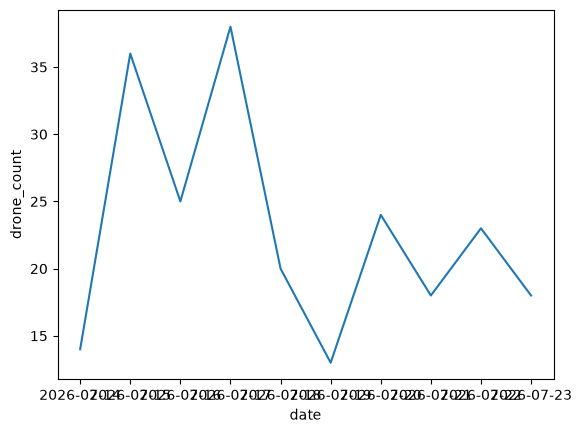

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

ax = sns.lineplot(data=df, x="date", y="drone_count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()